# 01. Data exploration

**Question:** what does the ESPN data actually cover, how clean is it, and what do the basic numbers look like
before we build anything on top of them?

Everything here reads from the PostgreSQL database built by `python -m src.etl.run`.

In [1]:
import sys
from pathlib import Path

# Let the notebook import from src/ when it's run from the notebooks folder.
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.database.connection import read_sql

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8, "axes.edgecolor": "#c3c2b7",
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left", "font.size": 10,
    "axes.prop_cycle": plt.cycler(color=["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]),
})
BLUE, ORANGE, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#c3c2b7"

## Coverage

One row per season: how many matches are finished or still to come, and which first-phase format was used.

In [2]:
coverage = read_sql('''
    SELECT s.label AS season, s.format,
           COUNT(*) FILTER (WHERE m.status = 'finished')  AS finished,
           COUNT(*) FILTER (WHERE m.status = 'scheduled') AS scheduled,
           COUNT(DISTINCT m.home_club_id)                 AS clubs
    FROM matches m JOIN seasons s ON s.season_id = m.season_id
    GROUP BY s.start_year, s.label, s.format ORDER BY s.start_year
''')
coverage

,season,format,finished,scheduled,clubs
0,2012-13,group_stage,125,0,32
1,2013-14,group_stage,125,0,32
2,2014-15,group_stage,125,0,32
3,2015-16,group_stage,125,0,32
4,2016-17,group_stage,125,0,32
5,2017-18,group_stage,125,0,32
6,2018-19,group_stage,125,0,32
7,2019-20,group_stage,119,0,32
8,2020-21,group_stage,125,0,32
9,2021-22,group_stage,125,0,32


125 matches a season under the old format (96 group games plus 29 knockout games), 189 under the 36-team
league. 2019-20 has 119 because the quarter-finals onwards were single games in Lisbon. 2026-27 has only
had one matchday so far.

## Which stats are missing, and when

ESPN returns 0 instead of leaving a stat out, so a column of zeros can mean "never recorded". The pipeline
measures the share of team-matches with a non-zero value for each stat and season
(`src/validation/checks.py`). Anything under 50% is stored as NULL. This shows the raw shares before that step.

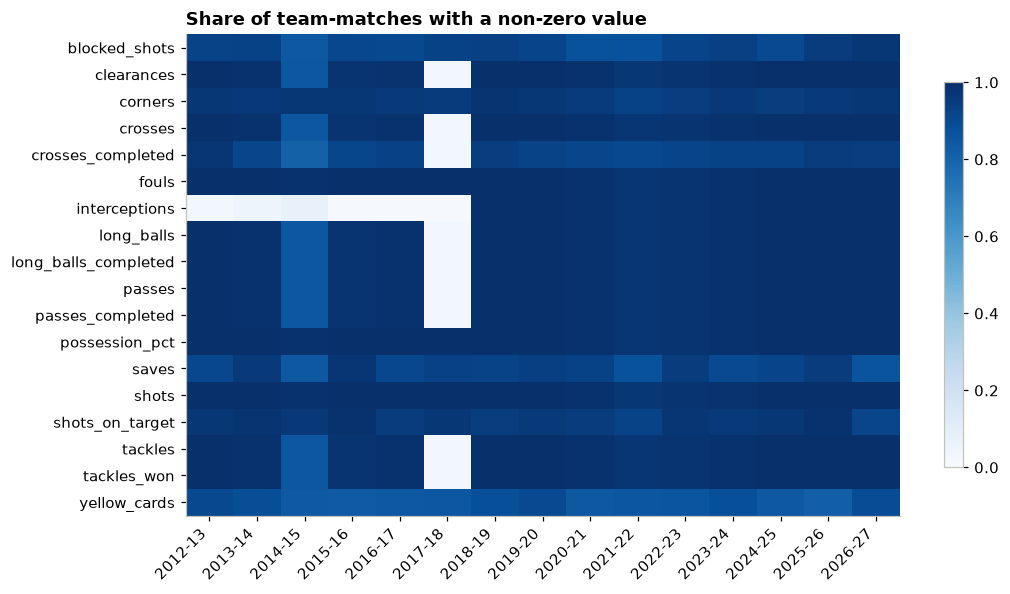

In [3]:
coverage_by_stat = pd.read_csv("../data/processed/validation_stat_coverage.csv")
grid = coverage_by_stat.pivot(index="stat", columns="season_year", values="nonzero_share")
grid = grid.drop(index=["red_cards", "offsides"])  # legitimately zero most of the time

fig, ax = plt.subplots(figsize=(10, 5.5))
image = ax.imshow(grid.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(grid.columns)), [f"{y}-{str(y + 1)[-2:]}" for y in grid.columns], rotation=45, ha="right")
ax.set_yticks(range(len(grid.index)), grid.index)
ax.grid(False)
ax.set_title("Share of team-matches with a non-zero value")
fig.colorbar(image, ax=ax, shrink=0.8)
plt.tight_layout()

Two gaps stand out:

- **Interceptions** are basically never recorded before 2018-19.
- **2017-18** is missing passes, crosses, long balls, tackles and clearances almost entirely.
- **2014-15** looks patchy too, but in a different way: about 15% of its matches have the whole passing and
  defending block at 0 while shots and possession are filled in. No team makes zero passes, so the pipeline
  treats any team-match with 0 passes as missing that block (312 team-matches across all seasons).

That's why the tactical clustering only uses 2018-19 onwards. Shots, shots on target, possession, fouls and
corners are there for every season.

## Checks that didn't pass cleanly

The pipeline compares each score with the goal events and with the players' goal totals. Mismatches are kept
but written to a report.

In [4]:
pd.read_csv("../data/processed/validation_inconsistent_scores.csv")

,espn_event_id,club,goals,event_goals,player_goals,own_goals_for,player_side_goals
0,720410,570,2.0,2.0,2,1.0,3.0
1,720410,2250,1.0,1.0,2,0.0,2.0


One match in 1,890: Club Brugge 2-1 Sporting CP (December 2024). ESPN counts Eduardo Quaresma's own goal as
both an own goal and a goal in his player stats, so Sporting's players "scored" 2. It's left as it is and
documented rather than patched by hand.

## How many goals in a match?

A common starting assumption in football models is that goals follow a Poisson distribution. If that's
roughly true, the variance should be close to the mean and the counts should match the Poisson shape.

1890 matches, mean 3.07 goals, variance 3.19


goals,0,1,2,3,4,5,6,7,8,9,10
observed,103.0,252.0,421.0,419.0,314.0,206.0,98.0,51.0,16.0,7.0,1.0
poisson,87.6,269.0,413.2,423.1,324.9,199.6,102.2,44.9,17.2,5.9,1.8


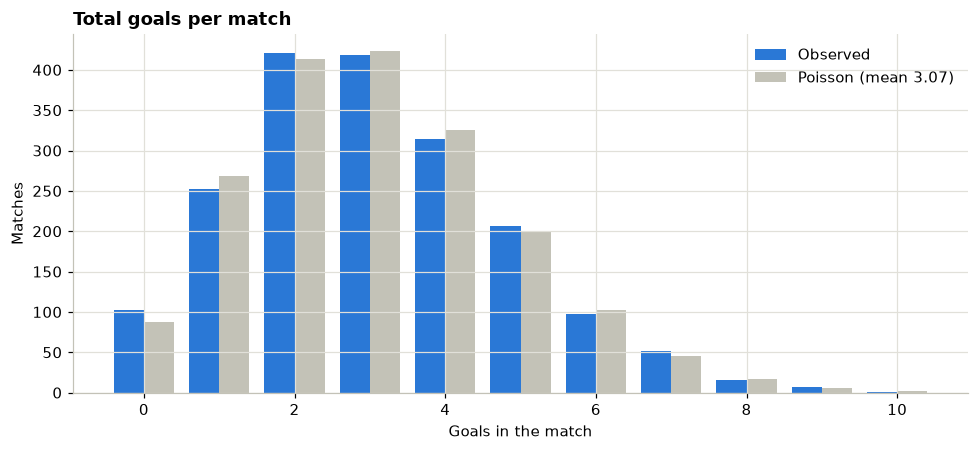

In [5]:
from scipy import stats

goals = read_sql("SELECT home_goals + away_goals AS goals FROM matches WHERE status = 'finished'")["goals"]
mean, variance = goals.mean(), goals.var()
print(f"{len(goals)} matches, mean {mean:.2f} goals, variance {variance:.2f}")

observed = goals.value_counts().sort_index().reindex(range(0, 11), fill_value=0)
expected = stats.poisson.pmf(observed.index, mean) * len(goals)

fig, ax = plt.subplots()
ax.bar(observed.index - 0.2, observed.values, width=0.4, label="Observed", color=BLUE)
ax.bar(observed.index + 0.2, expected, width=0.4, label=f"Poisson (mean {mean:.2f})", color=GREY)
ax.set(title="Total goals per match", xlabel="Goals in the match", ylabel="Matches")
ax.legend(frameon=False)
plt.tight_layout()

pd.DataFrame({"observed": observed, "poisson": expected.round(1)}).T

Close, but not exact. The variance (3.19) is a little above the mean (3.07), and there are more 0-0 games
than Poisson expects (103 against about 88). That fits the usual story: some games are cagey and both sides
are happy not to lose, which a model with independent goal rates doesn't capture.

For this project it's good enough to use Poisson for rough uncertainty ranges (the player per-90 intervals
use it), but it's a reason not to over-trust anything built purely on it.

## Home advantage over time

,season_year,season,home_win,draw,away_win,margin
0,2012,2012-13,0.468,0.218,0.315,0.315
1,2013,2013-14,0.500,0.185,0.315,0.363
2,2014,2014-15,0.508,0.226,0.266,0.524
3,2015,2015-16,0.548,0.194,0.258,0.573
4,2016,2016-17,0.452,0.266,0.282,0.653
5,2017,2017-18,0.444,0.210,0.347,0.347
6,2018,2018-19,0.460,0.218,0.323,0.484
7,2019,2019-20,0.446,0.205,0.348,0.259
8,2020,2020-21,0.411,0.194,0.395,0.008
9,2021,2021-22,0.452,0.210,0.339,0.234


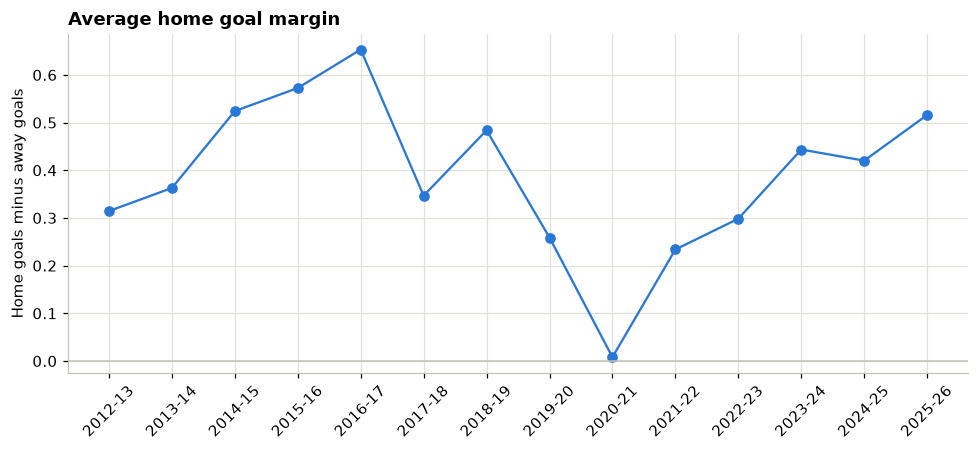

In [6]:
home = read_sql('''
    SELECT season_year, season,
           AVG((goals_for > goals_against)::INT) AS home_win,
           AVG((goals_for = goals_against)::INT) AS draw,
           AVG((goals_for < goals_against)::INT) AS away_win,
           AVG(goals_for - goals_against)        AS margin
    FROM v_club_matches
    WHERE is_home AND NOT is_neutral_venue AND season_year < 2026
    GROUP BY season_year, season ORDER BY season_year
''')

fig, ax = plt.subplots()
ax.plot(home["season"], home["margin"], marker="o", color=BLUE)
ax.axhline(0, color=GREY, linewidth=1)
ax.set(title="Average home goal margin", ylabel="Home goals minus away goals")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
home.round(3)

In a normal season home sides win by about 0.25 to 0.65 goals on average. In 2020-21, played almost entirely without
fans, the margin dropped to 0.01. That's one season, so it isn't proof on its own, but it lines up with
the research on closed-door football and it's why the prediction model treats home advantage as a feature
rather than a constant.

## Conclusion

- The data covers every main-tournament match from 2012-13, with consistent shots and possession numbers.
- Several defensive and passing stats are missing for older seasons, and the pipeline now stores those as
  NULL instead of 0.
- Only one match out of 1,890 has goals that don't add up, and it's documented.
- Goals are roughly Poisson with slightly too many 0-0s; home advantage is real and was much smaller in 2020-21.